[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter13_seminar_notebook.ipynb)

# Chapter 13: Machine Learning in Finance — Seminar Notebook (Bitcoin)

**Modelling Financial Markets (MFM)** · Bucharest University of Economic Studies · Daniel Traian Pele, Antoaneta Amza

Problems on daily Bitcoin (BTC-USD, 2014–2026) and Ether (ETH-USD, 2015–2026), matching the Seminar 13 slides.
**[Solved]** problems are worked models with full code; **[Proposed]** problems are for you — each follows an
analogous solved one. Every Part B problem ends with interpretation questions: *what would change the conclusion?*

| Part | Solved | Proposed |
|---|---|---|
| A — derivations (numerical checks) | A1 FFD weight sums, A3 barrier hitting probabilities, A5 SR variance and PSR/DSR, A7 purging loss, A9 AUC SE | A2 ADF over-rejection, A4 barriers with drift, A6 DSR and the Gumbel constant, A8 purging, A10 DeLong variance |
| B — Python | B1 BTC memory: ADF rule vs local Whittle, B3 triple barrier, B5 purged CV, B7 models + AUC CI, B9 meta-labelling, B10 DSR + effective $N$, B12 Pesaran–Timmermann and Clark–West | B2 ETH memory (a trap), B4 asymmetric barriers, B6 find the leak, B8 Diebold–Mariano, B11 PBO, B13 SPA vs DSR, B14 double selection |
| C — open | | C1 foundation model vs boosting |

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_13'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


> The solutions are discussed in the seminar.

## 0. Setup and toolbox

In [ ]:
import sys
if 'google.colab' in sys.modules:
    !pip -q install shap

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# MFM colour palette
MainBlue, IDAred, Forest, Amber = '#1A3A6E', '#CD0000', '#2E7D32', '#B5853F'
Orange, Purple, Gray, LightGray = '#E67E22', '#8E44AD', '#7F7F7F', '#DADADA'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': False,
                     'font.size': 9, 'axes.titlesize': 10, 'legend.frameon': False,
                     'figure.dpi': 110, 'figure.facecolor': 'none', 'axes.facecolor': 'none',
                     'savefig.facecolor': 'none', 'savefig.transparent': True})
SEED = 42


def legend_bottom(ax, ncol=2, y=-0.25, handles=None, labels=None, **kw):
    """Legend outside the axes, bottom centre (MFM chart style)."""
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)

In [ ]:
import os
DATA_URL = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
SERIES = {'sp500': 'GSPC.INDX', 'vix': 'VIX.INDX', 'btc': 'BTC-USD.CC', 'eth': 'ETH-USD.CC'}
START = {'sp500': '2000-01-01', 'vix': '2000-01-01', 'btc': '2014-09-17', 'eth': '2015-08-07'}


def load_data(name='sp500', start=None, end='2026-09-18'):
    """Daily OHLCV from the course data folder data/market: local copy, otherwise the file in the MFM GitHub repo."""
    fname = SERIES[name] + '.csv'
    local = [os.path.join(d, 'data', 'market', fname) for d in ('.', '..', '../..', '../../..')]
    path = next((p for p in local if os.path.exists(p)), DATA_URL + fname)
    df = pd.read_csv(path, parse_dates=['date']).set_index('date')
    df = df.rename(columns=str.capitalize)[['Open', 'High', 'Low', 'Close', 'Volume']]
    return df.loc[start or START[name]:end]


btc = load_data('btc')['Close']
log_btc = np.log(btc)
eth = load_data('eth')['Close']
log_eth = np.log(eth)
print('BTC:', btc.index[0].date(), '->', btc.index[-1].date(), len(btc), 'obs')
print('ETH:', eth.index[0].date(), '->', eth.index[-1].date(), len(eth), 'obs')

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.plot(btc.index, btc.values, color=MainBlue, lw=0.7, label='BTC-USD')
ax.plot(eth.index, eth.values, color=Amber, lw=0.7, label='ETH-USD')
ax.set_yscale('log'); ax.set_title('Prices (log scale)', loc='left'); legend_bottom(ax, ncol=2)
plt.tight_layout(); plt.show()

The toolbox below (from the lecture) is given: fractional differentiation, EWMA volatility,
triple-barrier labelling, purged K-fold, features, the Sharpe ratio and the PSR/DSR. Crypto trades 365 days a year, so we annualise with 365.

In [ ]:
def ffd_weights(d, threshold=1e-4, max_size=10_000):
    """w_k = -w_{k-1} (d - k + 1) / k, truncated when |w_k| < threshold."""
    w = [1.0]
    for k in range(1, max_size):
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k)
    return np.array(w)


def frac_diff_ffd(series, d, threshold=1e-4):
    """Fixed-width window fractional differentiation: X~_t = sum_k w_k X_{t-k}."""
    w = ffd_weights(d, threshold)
    x = series.dropna().values
    out = np.convolve(x, w, mode='valid')
    return pd.Series(out, index=series.dropna().index[len(w) - 1:])


def local_whittle(x, m=None, alpha=0.65):
    """Local Whittle estimate of the memory d (Robinson, 1995); returns (d_hat, SE = 1/(2 sqrt(m)))."""
    from scipy.optimize import minimize_scalar
    x = np.asarray(x, float); n = len(x); m = m or int(n ** alpha)
    lam = 2 * np.pi * np.arange(1, m + 1) / n
    I = np.abs(np.fft.fft(x - x.mean())[1:m + 1]) ** 2 / (2 * np.pi * n)
    R = lambda d: np.log(np.mean(lam ** (2 * d) * I)) - 2 * d * np.mean(np.log(lam))
    return minimize_scalar(R, bounds=(-0.49, 1.99), method='bounded').x, 1 / (2 * np.sqrt(m))


def exact_local_whittle(x, m=None, alpha=0.65):
    """Exact local Whittle (Shimotsu & Phillips, 2005), valid also for d >= 0.5; initial value removed (Shimotsu, 2010)."""
    from scipy.optimize import minimize_scalar
    x = np.asarray(x, float); x = x - x[0]; n = len(x); m = m or int(n ** alpha)
    lam = 2 * np.pi * np.arange(1, m + 1) / n
    k = np.arange(1, n); L = 2 ** int(np.ceil(np.log2(2 * n)))
    def R(d):
        pi = np.concatenate([[1.0], np.cumprod((k - 1 - d) / k)])
        u = np.fft.irfft(np.fft.rfft(x, L) * np.fft.rfft(pi, L), L)[:n]        # (1-B)^d x_t
        I = np.abs(np.fft.fft(u)[1:m + 1]) ** 2 / (2 * np.pi * n)
        return np.log(np.mean(I)) - 2 * d * np.mean(np.log(lam))
    return minimize_scalar(R, bounds=(-0.49, 1.99), method='bounded').x, 1 / (2 * np.sqrt(m))


def get_daily_vol(close, span=50):
    """EWMA volatility of daily log returns."""
    return np.log(close).diff().ewm(span=span).std()


def triple_barrier(close, events_idx, vol, pt=1.0, sl=1.0, horizon=10):
    """Triple-barrier labels: +1 upper, -1 lower, sign of the return at the vertical barrier."""
    logp = np.log(close)
    pos = {t: i for i, t in enumerate(close.index)}
    rows = []
    for t0 in events_idx:
        i0 = pos[t0]
        if i0 + 1 >= len(close) or np.isnan(vol.iloc[i0]):
            continue
        i1 = min(i0 + horizon, len(close) - 1)
        width = vol.iloc[i0] * np.sqrt(horizon)
        path = logp.iloc[i0 + 1:i1 + 1] - logp.iloc[i0]
        up = path[path >= pt * width].index.min() if pt > 0 else pd.NaT
        dn = path[path <= -sl * width].index.min() if sl > 0 else pd.NaT
        first = min([t for t in (up, dn) if pd.notna(t)], default=pd.NaT)
        if pd.isna(first):
            t1, barrier = close.index[i1], 'vertical'
            label = int(np.sign(path.iloc[-1])) if len(path) else 0
        else:
            t1 = first
            barrier = 'upper' if first == up else 'lower'
            label = 1 if barrier == 'upper' else -1
        rows.append((t0, t1, logp.loc[t1] - logp.iloc[i0], label, barrier, width))
    return pd.DataFrame(rows, columns=['t0', 't1', 'ret', 'label', 'barrier', 'width']).set_index('t0')


def rsi(close, n=14):
    delta = close.diff()
    up = delta.clip(lower=0).ewm(alpha=1 / n).mean()
    dn = (-delta.clip(upper=0)).ewm(alpha=1 / n).mean()
    return 100 - 100 / (1 + up / dn)


def build_features(close, vix=None, d_ffd=None):
    """Features that only use information available at time t (no look-ahead)."""
    lp = np.log(close)
    r = lp.diff()
    f = pd.DataFrame(index=close.index)
    for h in (1, 5, 20, 60, 120):
        f[f'mom_{h}'] = lp.diff(h)                                     # momentum over h days
    f['vol_20'] = r.rolling(20).std() * np.sqrt(252)
    f['vol_60'] = r.rolling(60).std() * np.sqrt(252)
    f['vol_ratio'] = f['vol_20'] / f['vol_60']
    f['dist_ma50'] = lp - lp.rolling(50).mean()
    f['dist_ma200'] = lp - lp.rolling(200).mean()
    f['rsi_14'] = rsi(close) / 100
    if vix is not None:
        v = np.log(vix.reindex(close.index).ffill())
        f['vix_level'] = v
        f['vix_chg_5'] = v.diff(5)
    if d_ffd is not None:
        f['ffd_price'] = frac_diff_ffd(lp, d_ffd)
    return f


def sharpe_ratio(returns, periods=252):
    """Annualised Sharpe ratio (zero risk-free rate)."""
    r = np.asarray(returns)
    return np.sqrt(periods) * r.mean() / r.std(ddof=1)


class PurgedKFold:
    """K-Fold without shuffling for overlapping labels.

    t1: pd.Series indexed by observation time t0, value = time t1 when the label is known.
    Purging: drop training observations whose [t0, t1] overlaps the test period.
    Embargo: also drop a fraction pct_embargo of observations right after the test set.
    """

    def __init__(self, n_splits=5, t1=None, pct_embargo=0.01):
        self.n_splits, self.t1, self.pct_embargo = n_splits, t1, pct_embargo

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        idx = np.arange(len(X))
        t0, t1 = self.t1.index.values, self.t1.values
        embargo = int(len(X) * self.pct_embargo)
        for test in np.array_split(idx, self.n_splits):
            start, stop = test[0], test[-1]
            test_t0, test_t1 = t0[start], t1[test].max()
            before = idx[t1 < test_t0]                                  # labels known before the test starts
            after_start = min(stop + 1 + embargo, len(X))               # embargo
            after = idx[after_start:][t0[after_start:] > test_t1]       # start after the last test label
            yield np.concatenate([before, after]), test


EULER_GAMMA = 0.5772156649015329


def probabilistic_sharpe_ratio(sr, sr_benchmark, T, skew=0.0, kurt=3.0):
    """PSR(SR*) = Phi((SR - SR*) sqrt(T-1) / sqrt(1 - g3 SR + (g4 - 1)/4 SR^2)); SR per period, kurt = raw kurtosis (Normal distribution = 3)."""
    denom = np.sqrt(1 - skew * sr + (kurt - 1) / 4 * sr ** 2)
    return stats.norm.cdf((sr - sr_benchmark) * np.sqrt(T - 1) / denom)


def expected_max_sharpe(n_trials, sr_std=1.0):
    """False Strategy Theorem: E[max SR] ~ sqrt(V[SR]) ((1-g) Phi^-1(1-1/N) + g Phi^-1(1-1/(N e)))."""
    n = np.asarray(n_trials, dtype=float)
    return sr_std * ((1 - EULER_GAMMA) * stats.norm.ppf(1 - 1 / n)
                     + EULER_GAMMA * stats.norm.ppf(1 - 1 / (n * np.e)))


def deflated_sharpe_ratio(sr, T, n_trials, sr_std, skew=0.0, kurt=3.0):
    """DSR = PSR(SR_0), SR_0 = E[max SR] under the null of no skill."""
    return probabilistic_sharpe_ratio(sr, expected_max_sharpe(n_trials, sr_std), T, skew, kurt)


## Part A — numerical checks of the pen-and-paper problems

### A1 [Solved] — FFD weights, their partial sums and the window length

In [5]:
from scipy.special import gamma as G
print(np.round(ffd_weights(0.5, threshold=0, max_size=5), 7))
d, tau = 0.25, 1e-4
w = ffd_weights(d, tau); K = len(w) - 1
print(f'd = {d}: K = {K}, approximation (tau |Gamma(-d)|)^(-1/(1+d)) = {(tau * abs(G(-d))) ** (-1 / (1 + d)):.0f}')
from scipy.special import gammaln
print(f'sum of weights = {w.sum():.4f}; Gamma(K+1-d)/(Gamma(1-d)Gamma(K+1)) = {np.exp(gammaln(K + 1 - d) - gammaln(1 - d) - gammaln(K + 1)):.4f}; '
      f'K^(-d)/Gamma(1-d) = {K ** (-d) / G(1 - d):.4f}')

[ 1.        -0.5       -0.125     -0.0625    -0.0390625]
d = 0.25: K = 444, approximation (tau |Gamma(-d)|)^(-1/(1+d)) = 444
sum of weights = 0.1777; Gamma(K+1-d)/(Gamma(1-d)Gamma(K+1)) = 0.1777; K^(-d)/Gamma(1-d) = 0.1778


### A2 [Proposed] — window length, weight sums and ADF over-rejection for $d = 0.3$ and $d = 0.5$

In [ ]:
# Your code here


### A3 [Solved] — triple-barrier labels of two short paths

In [7]:
def label_path(path, sigma, h, pt, sl):
    """Triple-barrier label of one price path (path[0] = entry price)."""
    width = sigma * np.sqrt(h)
    up, dn = path[0] * np.exp(pt * width), path[0] * np.exp(-sl * width)
    for day, p_ in enumerate(path[1:], start=1):
        if p_ >= up:
            return +1, day, round(up, 2), round(dn, 2)
        if p_ <= dn:
            return -1, day, round(up, 2), round(dn, 2)
    return int(np.sign(np.log(path[-1] / path[0]))), len(path) - 1, round(up, 2), round(dn, 2)

for path in ([100, 101.0, 100.4, 102.5, 101.2, 99.8], [100, 99.2, 98.6, 99.5, 98.9, 99.1]):
    print(label_path(path, 0.01, 5, 1, 1))

# Brownian benchmarks: time-out probability for symmetric barriers at +-sigma sqrt(h), h = 10 days
def p_no_touch(c, terms=50):
    # P(|W_s| < c for all s <= 1), c = barrier / (sigma sqrt(h))
    n = np.arange(terms)
    return 4 / np.pi * np.sum((-1) ** n / (2 * n + 1) * np.exp(-(2 * n + 1) ** 2 * np.pi ** 2 / (8 * c ** 2)))
print(f'continuous monitoring: {p_no_touch(1.0):.3f}; '
      f'daily monitoring, barrier shifted by 0.5826 sigma: {p_no_touch(1 + 0.5826 / np.sqrt(10)):.3f}')

(1, 3, np.float64(102.26), np.float64(97.79))
(-1, 5, np.float64(102.26), np.float64(97.79))
continuous monitoring: 0.371; daily monitoring, barrier shifted by 0.5826 sigma: 0.528


### A4 [Proposed] — asymmetric barriers, $pt = 2$, $sl = 1$

In [ ]:
# Your code here


### A5 [Solved] — PSR and DSR ($SR_{ann} = 1.2$, $T = 756$, $N = 100$)

In [9]:
sr, T = 1.2 / np.sqrt(252), 756
print(f'PSR(0) = {probabilistic_sharpe_ratio(sr, 0, T, -0.4, 5):.3f}')
sr0 = expected_max_sharpe(100, np.sqrt(1 / T))
print(f'SR0 = {sr0:.4f} (ann. {sr0 * np.sqrt(252):.2f}); DSR = {deflated_sharpe_ratio(sr, T, 100, np.sqrt(1 / T), -0.4, 5):.3f}')

PSR(0) = 0.979
SR0 = 0.0920 (ann. 1.46); DSR = 0.329


### A6 [Proposed] — PSR and DSR ($SR_{ann} = 1.5$, $T = 504$, $N = 20$)

In [ ]:
# Your code here


### A7 [Solved] — purging and embargo ($t_1 = i + 3$, test fold $\{8,\dots,11\}$)

In [11]:
def removed_sets(h):
    n = 20
    t1 = pd.Series(np.minimum(np.arange(n) + h, n - 1), index=np.arange(n))
    for tr, te in PurgedKFold(5, t1=t1, pct_embargo=0.05).split(np.zeros(n)):
        print('test', list(te), '| removed', sorted(set(range(n)) - set(tr) - set(te)), '| train', len(tr))

removed_sets(3)

test [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] | removed [4, 5, 6] | train 13
test [np.int64(4), np.int64(5), np.int64(6), np.int64(7)] | removed [1, 2, 3, 8, 9, 10] | train 10
test [np.int64(8), np.int64(9), np.int64(10), np.int64(11)] | removed [5, 6, 7, 12, 13, 14] | train 10
test [np.int64(12), np.int64(13), np.int64(14), np.int64(15)] | removed [9, 10, 11, 16, 17, 18] | train 10
test [np.int64(16), np.int64(17), np.int64(18), np.int64(19)] | removed [13, 14, 15] | train 13


### A8 [Proposed] — purging with $t_1 = i + 2$ (test fold $\{12,\dots,15\}$)

In [ ]:
# Your code here


### A9 [Solved] — AUC step by step and the Hanley–McNeil standard error

In [13]:
def auc_by_hand(pos, neg):
    U = sum((p_ > q_) + 0.5 * (p_ == q_) for p_ in pos for q_ in neg)
    A = U / (len(pos) * len(neg))
    Q1, Q2 = A / (2 - A), 2 * A ** 2 / (1 + A)
    se = np.sqrt((A * (1 - A) + (len(pos) - 1) * (Q1 - A ** 2) + (len(neg) - 1) * (Q2 - A ** 2)) / (len(pos) * len(neg)))
    return U, round(A, 4), round(se, 3), round((A - 0.5) / se, 2)

print('U, AUC, SE, z =', auc_by_hand([0.80, 0.55, 0.40], [0.60, 0.35, 0.20]))

U, AUC, SE, z = (7.0, 0.7778, np.float64(0.207), np.float64(1.34))


### A10 [Proposed] — AUC step by step (4 positives, 4 negatives)

In [ ]:
# Your code here


## B1 [Solved] — Memory of the BTC log price: the ADF rule vs local Whittle

**Task.** For $d \in \{0, 0.05, \dots, 1\}$ compute the FFD series of the BTC log price ($\tau = 10^{-4}$),
run the ADF test (constant, 1 lag) and record the statistic, the 5% critical value and the correlation
with the original log price. Find the smallest $d^*$ that rejects the unit root at 5%. Then estimate the memory directly: exact local Whittle
for the log price and the FFD series, local Whittle for returns and absolute returns, with 95% CIs ($m = n^{0.65}$).

**Interpretation.** Is $\hat d$ for the log price statistically different from 1? Is the FFD series at $d^*$ stationary? What would change $d^*$?

**Solution.**

d* (BTC) = 0.25, correlation with log price = 0.955


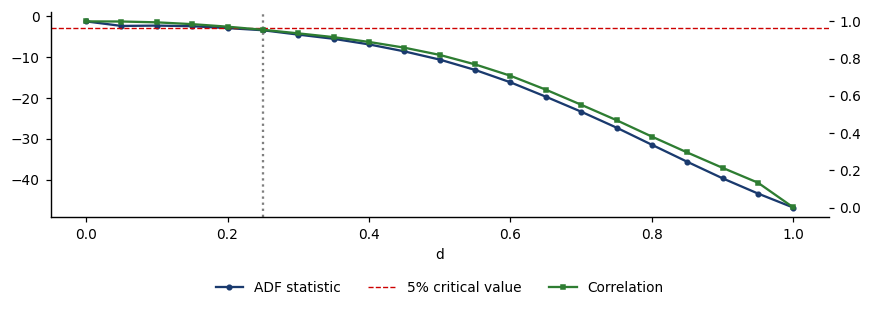

,adf,crit_5%,p_value,corr,n_obs
d,,,,,
0.00,-1.207,-2.862,0.671,1.000,4385
0.05,-2.321,-2.862,0.165,0.999,4024
0.10,-2.240,-2.862,0.192,0.995,3883
0.15,-2.389,-2.862,0.145,0.985,3859
0.20,-2.851,-2.862,0.051,0.972,3889
0.25,-3.376,-2.862,0.012,0.955,3941
0.30,-4.447,-2.862,0.000,0.936,3998
0.35,-5.478,-2.862,0.000,0.915,4054
0.40,-6.847,-2.862,0.000,0.890,4104


In [15]:
def min_d_table(logp, regression='c'):
    rows = []
    for d in np.round(np.arange(0, 1.01, 0.05), 2):
        x = frac_diff_ffd(logp, d).dropna()
        res = adfuller(x, maxlag=1, regression=regression, autolag=None)
        rows.append((d, res[0], res[4]['5%'], res[1], np.corrcoef(logp.loc[x.index], x)[0, 1], len(x)))
    t = pd.DataFrame(rows, columns=['d', 'adf', 'crit_5%', 'p_value', 'corr', 'n_obs']).set_index('d')
    return t, t.index[t['adf'] < t['crit_5%']].min()

ex1, d_star_btc = min_d_table(log_btc)
print(f'd* (BTC) = {d_star_btc}, correlation with log price = {ex1.loc[d_star_btc, "corr"]:.3f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ex1.index, ex1['adf'], 'o-', ms=3, color=MainBlue, label='ADF statistic')
ax.axhline(ex1['crit_5%'].iloc[0], color=IDAred, ls='--', lw=0.9, label='5% critical value')
ax.axvline(d_star_btc, color=Gray, ls=':')
ax2 = ax.twinx(); ax2.plot(ex1.index, ex1['corr'], 's-', ms=3, color=Forest, label='Correlation'); ax2.set_ylim(-0.05, 1.05)
ax.set_xlabel('d')
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
legend_bottom(ax, ncol=3, handles=h1 + h2, labels=l1 + l2)
plt.tight_layout(); plt.show()
ex1.round(3)

In [16]:
# memory estimated directly, with 95% CIs (m = n^0.65)
w_b = ffd_weights(d_star_btc)
print(f'sum of FFD weights at d* = {d_star_btc}: {w_b.sum():.3f}')
r_btc = log_btc.diff().dropna()
mem_b = {}
for lab, v, est in (('log price (ELW)', log_btc.values, exact_local_whittle),
                    (f'FFD d*={d_star_btc} (ELW)', frac_diff_ffd(log_btc, d_star_btc).values, exact_local_whittle),
                    ('returns (LW)', r_btc.values, local_whittle), ('|returns| (LW)', r_btc.abs().values, local_whittle)):
    dh, se = est(v)
    mem_b[lab] = (dh, dh - 1.96 * se, dh + 1.96 * se)
    print(f'{lab:22s} d_hat = {dh:.3f}, 95% CI [{dh - 1.96 * se:.3f}; {dh + 1.96 * se:.3f}]')
dh, se = exact_local_whittle(log_btc.values)
print(f'H0: d = 1 for the log price: z = {(dh - 1) / se:.2f}')

sum of FFD weights at d* = 0.25: 0.178
log price (ELW)        d_hat = 1.065, 95% CI [1.000; 1.129]
FFD d*=0.25 (ELW)      d_hat = 0.814, 95% CI [0.747; 0.880]
returns (LW)           d_hat = 0.063, 95% CI [-0.002; 0.127]
|returns| (LW)         d_hat = 0.353, 95% CI [0.289; 0.417]
H0: d = 1 for the log price: z = 1.97


## B2 [Proposed] — Memory of Ether: a trap

**Task.** Repeat B1 on the ETH log price (2015–2026). Then redo the $d = 0$ test with a constant **and a trend**
(`regression='ct'`) and redo B1 on the sample starting on 1 January 2018; add the exact local Whittle estimate with its CI on both samples.

**Interpretation.** Which $d^*$ would you use in a model, and why? What does this say about unit-root tests on assets
that grew 1,000-fold?

In [ ]:
# Your code here


## B3 [Solved] — Triple-barrier labels on BTC, $h=10$, pt = sl $\in\{1,2\}$

**Task.** Using an EWMA volatility (span 50), label every day of the BTC sample with the triple-barrier
method, vertical barrier $h = 10$ days and symmetric horizontal barriers pt = sl $\in\{1, 2\}$ (in units of
$\sigma_{t_0}\sqrt h$). Report the share of upper / lower / vertical touches and the average holding period,
and compare with 10-day fixed-horizon labels.

**Interpretation.** Why are about 56% of the labels $+1$, and what is then the benchmark accuracy of a classifier?

**Solution.**

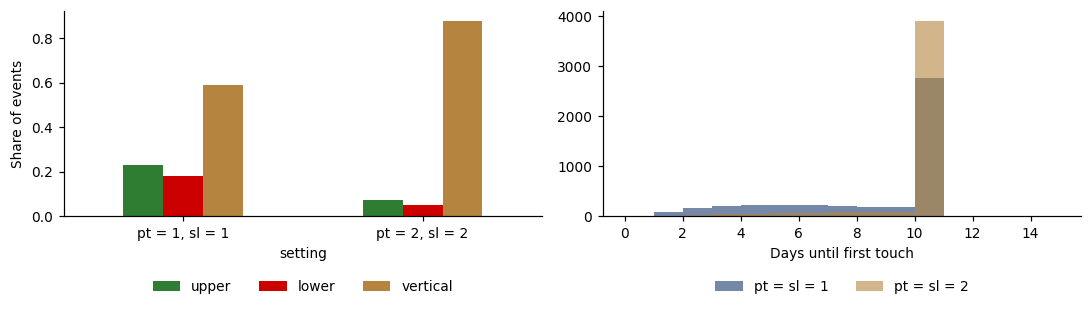

,upper,lower,vertical,avg_days,share_+1
setting,,,,,
"pt = 1, sl = 1",0.227,0.182,0.591,8.241,0.558
"pt = 2, sl = 2",0.072,0.049,0.879,9.572,0.557
fixed horizon 10d,NaN,NaN,1.000,10.000,0.553


In [18]:
vol_b = get_daily_vol(btc)
events = btc.index                                   # every day is an event
fixed = np.sign(log_btc.shift(-10) - log_btc).reindex(events)


def barrier_table(settings):
    rows, tbs = [], {}
    for pt_, sl_ in settings:
        tb = triple_barrier(btc, events, vol_b, pt=pt_, sl=sl_, horizon=10)
        tbs[(pt_, sl_)] = tb
        share = tb['barrier'].value_counts(normalize=True).reindex(['upper', 'lower', 'vertical']).fillna(0)
        rows.append((f'pt = {pt_}, sl = {sl_}', share['upper'], share['lower'], share['vertical'],
                     (tb['t1'] - tb.index).dt.days.mean(), (tb['label'] > 0).mean()))
    return pd.DataFrame(rows, columns=['setting', 'upper', 'lower', 'vertical', 'avg_days', 'share_+1']).set_index('setting'), tbs

ex3, tbs = barrier_table([(1, 1), (2, 2)])
ex3.loc['fixed horizon 10d'] = [np.nan, np.nan, 1.0, 10.0, (fixed > 0).mean()]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
ex3.iloc[:2][['upper', 'lower', 'vertical']].plot.bar(ax=axes[0], color=[Forest, IDAred, Amber], rot=0, legend=False)
axes[0].set_ylabel('Share of events'); legend_bottom(axes[0], ncol=3)
for k, c in zip(tbs, (MainBlue, Amber)):
    axes[1].hist((tbs[k]['t1'] - tbs[k].index).dt.days, bins=np.arange(0, 16), alpha=0.6, color=c, label=f'pt = sl = {k[0]}')
axes[1].set_xlabel('Days until first touch'); legend_bottom(axes[1], ncol=2)
plt.tight_layout(); plt.show()
ex3.round(3)

## B4 [Proposed] — Asymmetric barriers on BTC

**Task.** Repeat B3 with $(pt, sl) = (2, 1)$ and $(1, 2)$; report the exit shares, the share of $+1$ labels and the average
holding period. Check your answer to A4 on real data.

**Interpretation.** Which setting would a trend follower choose? How does the choice change the class balance a classifier sees?

In [ ]:
# Your code here


## B5 [Solved] — Implement PurgedKFold and compare with shuffled K-Fold on the leakage dataset

**Task.** (a) Write a class `PurgedKFold(n_splits, t1, pct_embargo)` with a scikit-learn-style `split(X)`
(the toolbox cell contains a reference implementation). (b) On the leakage dataset below (a random walk: there is
nothing to predict), compare the out-of-fold accuracy of a random forest under shuffled K-Fold, unshuffled K-Fold and PurgedKFold.

**Interpretation.** Would the gap shrink with non-persistent features? With 1-day labels?

In [20]:
# Leakage dataset (given)
rng = np.random.default_rng(SEED)
n, h = 3000, 20
p = pd.Series(np.cumsum(rng.normal(0, 0.01, n + h)))
y_leak = (p.shift(-h) - p > 0).astype(int).iloc[:n].values          # overlapping 20-day labels
X_leak = np.column_stack([pd.Series(rng.normal(size=n + h)).rolling(h).mean().bfill().iloc[:n] for _ in range(5)])
t1_leak = pd.Series(np.arange(n) + h, index=np.arange(n))            # label of obs i is known at i + h

**Solution.**

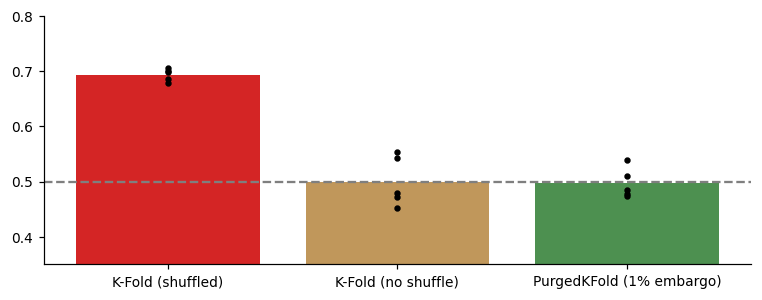

K-Fold (shuffled)           0.694
K-Fold (no shuffle)         0.500
PurgedKFold (1% embargo)    0.497
dtype: float64

In [21]:
schemes = {'K-Fold (shuffled)': KFold(5, shuffle=True, random_state=SEED),
           'K-Fold (no shuffle)': KFold(5, shuffle=False),
           'PurgedKFold (1% embargo)': PurgedKFold(5, t1=t1_leak, pct_embargo=0.01)}
model = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=SEED)
ex5 = {}
for name, cv_ in schemes.items():
    ex5[name] = [accuracy_score(y_leak[te], model.fit(X_leak[tr], y_leak[tr]).predict(X_leak[te]))
                 for tr, te in cv_.split(X_leak)]
ex5 = pd.DataFrame(ex5)

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(range(3), ex5.mean(), color=[IDAred, Amber, Forest], alpha=0.85)
for i, col in enumerate(ex5):
    ax.scatter(np.full(5, i), ex5[col], color='black', s=10, zorder=3)
ax.axhline(0.5, color=Gray, ls='--'); ax.set_xticks(range(3), ex5.columns); ax.set_ylim(0.35, 0.8)
plt.tight_layout(); plt.show()
ex5.mean().round(3)

## B6 [Proposed] — Find the leak

**Task.** The cell below adds a 12th feature, `ma11`, to the B7 feature set. With **purged** 5-fold CV the random forest
now reaches a spectacular accuracy on the BTC 5-day direction. Purging did not stop it: find the leak (read how `ma11`
is built and rank the features by MDI), fix it and report the honest result.

**Interpretation.** Why can purging not catch this kind of leak? Give a second example of look-ahead in a feature pipeline.

In [ ]:
# Modelling frame shared by B6-B8 (given)
H = 5
feats_b = build_features(btc)
FB = list(feats_b.columns)
dfb = feats_b.assign(fwd=log_btc.shift(-H) - log_btc).dropna()
dfb['y'] = (dfb['fwd'] > 0).astype(int)
pos = np.searchsorted(btc.index, dfb.index)
dfb['t1'] = btc.index[np.minimum(pos + H, len(btc) - 1)]
Xb, yb = dfb[FB].values, dfb['y'].values

# the suspicious feature (given)
r1 = log_btc.diff()
df6 = dfb.copy()
df6['ma11'] = r1.rolling(11, center=True).mean().reindex(df6.index)
df6 = df6.dropna()
rf6 = RandomForestClassifier(n_estimators=300, min_samples_leaf=50, max_features='sqrt', n_jobs=-1, random_state=SEED)
cv6 = PurgedKFold(5, t1=df6['t1'], pct_embargo=0.01)


def purged_oos(cols):
    Xs, ys = df6[cols].values, df6['y'].values
    pr = np.full(len(ys), np.nan)
    for tr, te in cv6.split(Xs):
        pr[te] = rf6.fit(Xs[tr], ys[tr]).predict_proba(Xs[te])[:, 1]
    return accuracy_score(ys, pr > 0.5), roc_auc_score(ys, pr)

acc, auc = purged_oos(FB + ['ma11'])
print(f'with ma11: accuracy {acc:.3f}, AUC {auc:.3f}')

In [ ]:
# Your code here


## B7 [Solved] — Logit-L1 vs Random Forest vs Gradient Boosting, feature importance, and a CI for the AUC

**Task.** Compare an $L_1$-penalised logistic regression, a random forest and gradient boosting on the BTC 5-day direction
with **purged** 5-fold CV (1% embargo): accuracy, ROC AUC and the "always up" benchmark; compare MDI, MDA and mean |SHAP|.
Then take the pooled out-of-fold probabilities of the random forest and compute a 95% CI for its AUC twice: with the
DeLong standard error (independent observations) and with a circular block bootstrap ($L = 1, 20, 60$; 1,000 replications).

**Interpretation.** Why is the bootstrap interval wider? Which block length would you defend?

**Solution.**

In [24]:
print(dfb.shape, '| share up =', round(yb.mean(), 3))
models = {
    'Logit-L1': make_pipeline(StandardScaler(), LogisticRegression(penalty='l1', C=0.05, solver='liblinear')),
    'Random Forest': RandomForestClassifier(n_estimators=400, min_samples_leaf=50, max_features='sqrt',
                                            n_jobs=-1, random_state=SEED),
    'Gradient Boosting': HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=200,
                                                        min_samples_leaf=50, random_state=SEED),
}
cv = PurgedKFold(5, t1=dfb['t1'], pct_embargo=0.01)
oos = {k: np.full(len(yb), np.nan) for k in models}
const = np.full(len(yb), np.nan)                     # constant forecast: training share of up days
rows = []
for name, m in models.items():
    acc, auc, base = [], [], []
    for tr, te in cv.split(Xb):
        prob = m.fit(Xb[tr], yb[tr]).predict_proba(Xb[te])[:, 1]
        oos[name][te] = prob
        const[te] = yb[tr].mean()
        acc.append(accuracy_score(yb[te], prob > 0.5)); auc.append(roc_auc_score(yb[te], prob))
        base.append(max(yb[te].mean(), 1 - yb[te].mean()))
    rows.append((name, np.mean(acc), np.std(acc), np.mean(auc), np.std(auc), np.mean(base)))
ex7 = pd.DataFrame(rows, columns=['model', 'accuracy', 'acc_sd', 'AUC', 'auc_sd', 'always_up']).set_index('model')
ex7.round(3)

(4181, 14) | share up = 0.548


,accuracy,acc_sd,AUC,auc_sd,always_up
model,,,,,
Logit-L1,0.548,0.037,0.492,0.025,0.548
Random Forest,0.542,0.028,0.516,0.036,0.548
Gradient Boosting,0.522,0.022,0.502,0.023,0.548


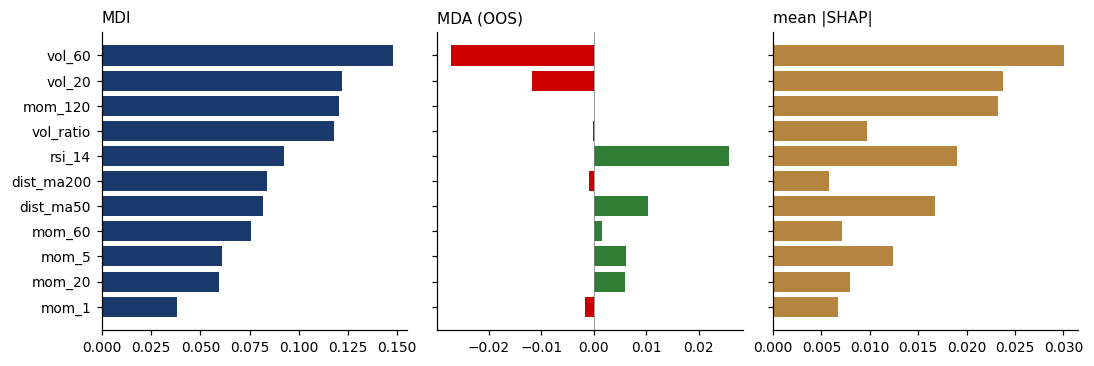

Spearman rank correlations:
       MDI   MDA  SHAP
MDI   1.00 -0.42  0.75
MDA  -0.42  1.00 -0.10
SHAP  0.75 -0.10  1.00


In [25]:
split = int(len(dfb) * 0.7)
gap = split + H + int(0.01 * len(dfb))
Xbdf = dfb[FB]
rf = RandomForestClassifier(n_estimators=400, min_samples_leaf=50, max_features='sqrt',
                            n_jobs=-1, random_state=SEED).fit(Xbdf.iloc[:split], yb[:split])
mdi = pd.Series(rf.feature_importances_, index=FB)
mda = pd.Series(permutation_importance(rf, Xbdf.iloc[gap:], yb[gap:], scoring='roc_auc', n_repeats=10,
                                       random_state=SEED, n_jobs=-1).importances_mean, index=FB)
try:
    import shap
    sv = shap.TreeExplainer(rf).shap_values(Xbdf.iloc[gap:].sample(300, random_state=SEED))
    sv = sv[1] if isinstance(sv, list) else (sv[..., 1] if np.ndim(sv) == 3 else sv)
    shp = pd.Series(np.abs(sv).mean(0), index=FB)
except Exception as e:
    print('SHAP skipped:', e)
    shp = pd.Series(np.nan, index=FB)
imp_b = pd.DataFrame({'MDI': mdi, 'MDA': mda, 'SHAP': shp}).sort_values('MDI')

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), sharey=True)
axes[0].barh(imp_b.index, imp_b['MDI'], color=MainBlue); axes[0].set_title('MDI', loc='left')
axes[1].barh(imp_b.index, imp_b['MDA'], color=np.where(imp_b['MDA'] > 0, Forest, IDAred))
axes[1].axvline(0, color=Gray, lw=0.5); axes[1].set_title('MDA (OOS)', loc='left')
axes[2].barh(imp_b.index, imp_b['SHAP'], color=Amber); axes[2].set_title('mean |SHAP|', loc='left')
plt.tight_layout(); plt.show()
print('Spearman rank correlations:')
print(imp_b.corr(method='spearman').round(2))

RF pooled AUC = 0.512; DeLong SE = 0.0090, CI [0.495; 0.530], z = 1.37, p = 0.170


L =  1: SE = 0.0091, CI [0.494; 0.530], share of replications <= 0.5 = 0.079


L = 20: SE = 0.0150, CI [0.484; 0.543], share of replications <= 0.5 = 0.209


L = 60: SE = 0.0141, CI [0.485; 0.541], share of replications <= 0.5 = 0.186


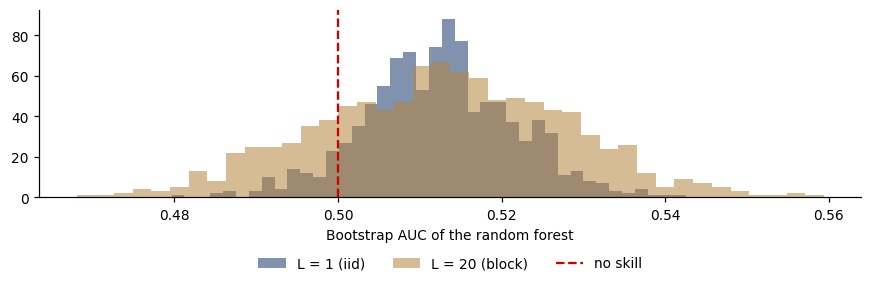

In [26]:
def delong_auc(y, s):
    """AUC and its DeLong variance (independent observations)."""
    pos, neg = s[y == 1], s[y == 0]
    m1, n0 = len(pos), len(neg)
    rk = stats.rankdata(np.concatenate([pos, neg]))
    auc = (rk[:m1].sum() - m1 * (m1 + 1) / 2) / (m1 * n0)
    v10 = (rk[:m1] - stats.rankdata(pos)) / n0
    v01 = 1 - (rk[m1:] - stats.rankdata(neg)) / m1
    return auc, np.var(v10, ddof=1) / m1 + np.var(v01, ddof=1) / n0


def cbb_index(n, L, rng):
    """Circular block bootstrap indices, block length L."""
    starts = rng.integers(0, n, int(np.ceil(n / L)))
    return ((starts[:, None] + np.arange(L)[None, :]).ravel() % n)[:n]

s_rf = oos['Random Forest']
auc_rf, var_rf = delong_auc(yb, s_rf)
se_d = np.sqrt(var_rf)
print(f'RF pooled AUC = {auc_rf:.3f}; DeLong SE = {se_d:.4f}, CI [{auc_rf - 1.96 * se_d:.3f}; {auc_rf + 1.96 * se_d:.3f}], '
      f'z = {(auc_rf - 0.5) / se_d:.2f}, p = {2 * (1 - stats.norm.cdf(abs(auc_rf - 0.5) / se_d)):.3f}')
rng = np.random.default_rng(SEED)
boot = {}
for L in (1, 20, 60):
    bs = []
    for _ in range(1000):
        i = cbb_index(len(yb), L, rng)
        if yb[i].min() == yb[i].max():
            continue
        bs.append(roc_auc_score(yb[i], s_rf[i]))
    boot[L] = np.array(bs)
    print(f'L = {L:2d}: SE = {boot[L].std():.4f}, CI [{np.quantile(boot[L], .025):.3f}; {np.quantile(boot[L], .975):.3f}], '
          f'share of replications <= 0.5 = {np.mean(boot[L] <= 0.5):.3f}')

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.hist(boot[1], bins=40, alpha=0.55, color=MainBlue, label='L = 1 (iid)')
ax.hist(boot[20], bins=40, alpha=0.55, color=Amber, label='L = 20 (block)')
ax.axvline(0.5, color=IDAred, ls='--', label='no skill')
ax.set_xlabel('Bootstrap AUC of the random forest'); legend_bottom(ax, ncol=3)
plt.tight_layout(); plt.show()

## B8 [Proposed] — Diebold–Mariano test on probability forecasts

**Task.** Use the pooled out-of-fold probabilities of B7 and the constant forecast `const` (training share of "up" days in each fold).
For the log loss $\ell_t = -[y_t\ln\hat p_t + (1-y_t)\ln(1-\hat p_t)]$ compute the loss differential $d_t = \ell^A_t - \ell^B_t$ and the
DM statistic $\bar d/\mathrm{SE}_{HAC}(\bar d)$ with Newey–West lags 4 and 20; compare with the naive i.i.d. $t$.
Pairs: RF vs Logit-L1, RF vs constant, GB vs constant.

**Interpretation.** Can a model with AUC above 0.5 lose to a constant in log loss? What would change the conclusion?

In [ ]:
# Your code here


## B12 [Solved] — Pesaran–Timmermann and Clark–West on the BTC direction models

**Task.** Using the pooled out-of-fold probabilities of B7: (a) for each model, the Pesaran–Timmermann statistic of the predicted signs
($\hat p > 0.5$) and, because the 5-day labels overlap, the slope $t$-statistic of $y_t = a + b\,x_t + u_t$ with Newey–West errors (4 lags);
(b) the Clark–West test of Logit-L1 against the constant forecast (nested models, Brier loss, HAC $t$), next to the plain DM test on the same loss.

**Interpretation.** Why can DM and Clark–West disagree for nested models? Which null does each test?

**Solution.**

In [28]:
def pesaran_timmermann(y, x):
    n = len(y); P = np.mean(y == x); py, px = y.mean(), x.mean()
    Ps = py * px + (1 - py) * (1 - px)
    VP = Ps * (1 - Ps) / n
    VPs = (2 * py - 1) ** 2 * px * (1 - px) / n + (2 * px - 1) ** 2 * py * (1 - py) / n + 4 * py * px * (1 - py) * (1 - px) / n ** 2
    return P, Ps, (P - Ps) / np.sqrt(VP - VPs)

import statsmodels.api as sm
ex12 = []
for name, pr in oos.items():
    x = (pr > 0.5).astype(int)
    P, Ps, pt_stat = pesaran_timmermann(yb, x)
    t_hac = sm.OLS(yb, sm.add_constant(x)).fit(cov_type='HAC', cov_kwds={'maxlags': 4}).tvalues[1]
    ex12.append((name, x.mean(), P, Ps, pt_stat, t_hac))
print(pd.DataFrame(ex12, columns=['model', 'share_pred_up', 'P', 'P*', 'PT', 't_HAC']).set_index('model').round(3))
p1, p0 = oos['Logit-L1'], const
f = (yb - p0) ** 2 - ((yb - p1) ** 2 - (p0 - p1) ** 2)
cw = sm.OLS(f, np.ones(len(f))).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
dm = sm.OLS((yb - p1) ** 2 - (yb - p0) ** 2, np.ones(len(f))).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(f'Clark-West (Logit-L1 vs constant): t = {cw.tvalues[0]:.2f}, one-sided p = {1 - stats.norm.cdf(cw.tvalues[0]):.3f}')
print(f'DM (Brier, Logit-L1 - constant): t = {dm.tvalues[0]:.2f} (positive = logit worse)')

                   share_pred_up      P     P*     PT  t_HAC
model                                                       
Logit-L1                   0.996  0.548  0.548  0.890  0.822
Random Forest              0.703  0.542  0.519  3.198  2.212
Gradient Boosting          0.685  0.522  0.518  0.646  0.446
Clark-West (Logit-L1 vs constant): t = -0.56, one-sided p = 0.712
DM (Brier, Logit-L1 - constant): t = 1.37 (positive = logit worse)


## B9 [Solved] — Meta-labelling: primary 20/50 MA crossover, secondary RF → precision/recall/F1 before vs after

**Task.** *Primary model:* $s_t = \operatorname{sign}(MA_{20,t} - MA_{50,t})$ (long if $+1$, short if $-1$). For every day, open a trade in direction $s_t$ and
label its outcome with the triple barrier ($h = 10$, pt = sl = 1): the **meta-label** is $1$ if $s_t \cdot r_{t_0,t_1} > 0$, else $0$.
*Secondary model:* a random forest (balanced class weights) on the features plus $s_t$, trained on the first 60% of the signals and
evaluated on the last 40% after a 10-day gap. Compare precision, recall and F1 before (all trades) and after (only $\hat p > 0.5$).

**Interpretation.** Precision up, F1 down: which metric matters for a trader who pays costs per trade?

**Solution.**

In [29]:
side = np.sign(btc.rolling(20).mean() - btc.rolling(50).mean())
feats_m = build_features(btc)
valid = feats_m.dropna().index.intersection(side[side != 0].dropna().index)
events_m = valid[valid <= btc.index[-13]]                          # full 10-day window available
tb_m = triple_barrier(btc, events_m, get_daily_vol(btc), pt=1.0, sl=1.0, horizon=10)

meta = pd.DataFrame({'side': side.reindex(tb_m.index), 't1': tb_m['t1']})
meta['ret_side'] = tb_m['ret'] * meta['side']                     # trade return in the primary direction
meta['y'] = (meta['ret_side'] > 0).astype(int)                    # meta-label
Xm = feats_m.reindex(meta.index).assign(side=meta['side'])

split = int(0.6 * len(meta))
test0 = split + 10                                                 # 10-day gap between train and test
rf_meta = RandomForestClassifier(n_estimators=400, min_samples_leaf=50, max_features='sqrt',
                                 class_weight='balanced', n_jobs=-1, random_state=SEED)
rf_meta.fit(Xm.iloc[:split], meta['y'].iloc[:split])
test = meta.iloc[test0:]
prob_m = rf_meta.predict_proba(Xm.iloc[test0:])[:, 1]
take = prob_m > 0.5
ym = test['y'].values
print(f'test period: {test.index[0].date()} -> {test.index[-1].date()}, {len(test)} signals; '
      f'meta-model takes {take.mean():.1%} of trades')

p0 = ym.mean()
ex9 = pd.DataFrame({
    'primary only (all trades)': [p0, 1.0, 2 * p0 / (1 + p0), len(ym),
                                                                           test['ret_side'].mean()],
    'primary + meta-labelling': [precision_score(ym, take), recall_score(ym, take), f1_score(ym, take),
                                                           int(take.sum()), test['ret_side'][take].mean()]},
    index=['precision', 'recall', 'F1', 'n_trades', 'avg_ret_per_trade'])
ex9.round(4)

test period: 2022-02-20 -> 2026-09-06, 1660 signals; meta-model takes 49.6% of trades


,primary only (all trades),primary + meta-labelling
precision,0.4747,0.5170
recall,1.0000,0.5406
F1,0.6438,0.5285
n_trades,1660.0000,824.0000
avg_ret_per_trade,-0.0027,0.0019


## B10 [Solved] — Grid search, DSR and the effective number of trials

**Task.** Search over long/cash moving-average crossover strategies on BTC from 2015 onwards (fast window 5–55, slow window 20–240),
take the best by Sharpe ratio and compute its PSR and DSR. Then estimate the **effective** number of trials from the correlation matrix of the
trials' daily returns: eigenvalues $\lambda_i$, participation ratio $(\sum\lambda_i)^2/\sum\lambda_i^2$, number of eigenvalues reaching 95%,
and $\hat N = \bar\rho + (1-\bar\rho)N$; recompute the DSR for each $N$.

**Interpretation.** Which $N$ and which $V[\widehat{SR}]$ would you report to an investment committee?

**Solution.**

N = 120, T = 4279; best = (np.int64(5), np.int64(40)), SR_ann = 1.17; buy & hold SR_ann = 0.71; skew = 0.11, kurtosis = 13.0
PSR(0) = 1.000


largest eigenvalue = 105.2 (87.7%); participation ratio = 1.30; 95%: 4; mean correlation = 0.873 -> N_hat = 16.1


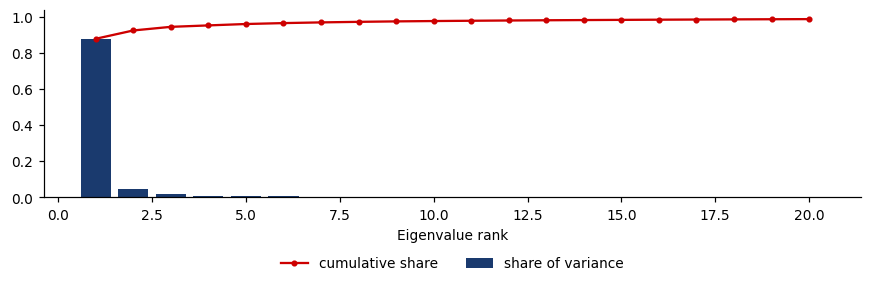

,case,N,V,SR0_ann,DSR
0,N = 120,120.0,V = 1/T,0.758,0.922
1,N = 120,120.0,V from trials,0.244,0.999
2,N_hat,16.1,V = 1/T,0.527,0.986
3,N_hat,16.1,V from trials,0.170,1.000
4,95% eigen,4.0,V = 1/T,0.307,0.998
5,95% eigen,4.0,V from trials,0.099,1.000


In [30]:
r_b = log_btc.diff()
rets = {}
for fast in range(5, 60, 5):
    for slow in range(20, 260, 20):
        if slow <= fast:
            continue
        sig = (log_btc.rolling(fast).mean() > log_btc.rolling(slow).mean()).astype(float).shift(1)   # MAs of log price; trade next day
        rets[(fast, slow)] = (sig * r_b).loc['2015-01-01':]
R = pd.DataFrame(rets).dropna()
N, T10 = R.shape[1], len(R)
srs = R.mean() / R.std()                                            # per-period SR of each trial
best = srs.idxmax()
s_best = R[best]
sk10, ku10 = stats.skew(s_best), stats.kurtosis(s_best, fisher=False)
bh = r_b.loc[R.index]
print(f'N = {N}, T = {T10}; best = {best}, SR_ann = {srs[best] * np.sqrt(365):.2f}; '
      f'buy & hold SR_ann = {bh.mean() / bh.std() * np.sqrt(365):.2f}; skew = {sk10:.2f}, kurtosis = {ku10:.1f}')
print(f'PSR(0) = {probabilistic_sharpe_ratio(srs[best], 0, T10, sk10, ku10):.3f}')

C = np.corrcoef(R.values.T)
lam = np.linalg.eigvalsh(C)[::-1]
n_pr = lam.sum() ** 2 / (lam ** 2).sum()
n95 = int(np.searchsorted(np.cumsum(lam) / lam.sum(), 0.95) + 1)
rho_bar = (C.sum() - N) / (N * (N - 1))
n_rho = rho_bar + (1 - rho_bar) * N
print(f'largest eigenvalue = {lam[0]:.1f} ({lam[0] / lam.sum():.1%}); participation ratio = {n_pr:.2f}; '
      f'95%: {n95}; mean correlation = {rho_bar:.3f} -> N_hat = {n_rho:.1f}')
rows = []
for label, Nx in (('N = 120', N), ('N_hat', n_rho), ('95% eigen', n95)):
    for vlab, sd in (('V = 1/T', np.sqrt(1 / T10)), ('V from trials', srs.std())):
        rows.append((label, round(Nx, 1), vlab, expected_max_sharpe(max(Nx, 1.0001), sd) * np.sqrt(365),
                     deflated_sharpe_ratio(srs[best], T10, max(Nx, 1.0001), sd, sk10, ku10)))
ex10 = pd.DataFrame(rows, columns=['case', 'N', 'V', 'SR0_ann', 'DSR'])

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.bar(np.arange(1, 21), lam[:20] / lam.sum(), color=MainBlue, label='share of variance')
ax.plot(np.arange(1, 21), np.cumsum(lam[:20]) / lam.sum(), 'o-', ms=3, color=IDAred, label='cumulative share')
ax.set_xlabel('Eigenvalue rank'); legend_bottom(ax, ncol=2)
plt.tight_layout(); plt.show()
ex10.round(3)

## B11 [Proposed] — Probability of backtest overfitting (CSCV)

**Task.** Split the matrix `R` of B10 (daily returns of the 120 trials) into $S = 16$ contiguous blocks. For each of the
$\binom{16}{8} = 12{,}870$ ways to choose 8 blocks as in-sample (the rest out-of-sample): pick the trial with the best in-sample Sharpe,
compute its relative rank $\omega$ out of sample and the logit $\lambda = \ln\frac{\omega}{1-\omega}$. Report $\mathrm{PBO} = P(\lambda \leq 0)$
and the median out-of-sample Sharpe of the in-sample winner.

**Interpretation.** Is the grid overfit? How would $S$, or adding 1,000 random strategies to the grid, change the PBO?

In [ ]:
# Your code here


## B13 [Proposed] — SPA vs DSR on the 120-rule grid

**Task.** For the 120 trials of B10 compute White's Reality Check, Hansen's SPA ($p$-value with the consistent recentring) and the
Romano–Wolf StepM (5%) with the stationary bootstrap (mean block 20 days, 2,000 replications), against two benchmarks: cash and buy-and-hold.
Compare with the DSR of B10 under $N = 120$ and $\hat N = 16.1$. Model: B10 and B12.

**Interpretation.** Which method handles correlated trials without choosing $N$? Does the grid beat buy-and-hold?

In [ ]:
# Your code here


## B14 [Proposed] — Double selection: does the VIX predict Bitcoin returns?

**Task.** Outcome: the 5-day forward BTC log return of B7 (in basis points); regressor of interest: the log VIX of the same day (last
available close), standardised; controls: the 11 B7 features, their squares and pairwise products ($p = 77$), standardised.
(a) LASSO of $y$ on (VIX, controls) with the plug-in penalty of Belloni, Chernozhukov & Hansen (2014): is the VIX kept?
(b) Post-double selection: coefficient, HAC standard error (4 lags) and 95% CI. Model: the lecture example (S&P 500).

**Interpretation.** Why does the single LASSO give no valid inference? What does the CI say about a crypto "fear premium"?

In [ ]:
# Your code here


## C1 [Proposed] — Does a time-series foundation model beat gradient boosting?

**Question.** Does a time-series foundation model (Chapter 14), used zero-shot, beat gradient boosting for the BTC 5-day direction once
purged validation, a Diebold–Mariano test and the DSR are applied? There is no single method: propose one and defend it.

**Deliverable.** A Quantlet folder in the team repository (code, `Metainfo.txt`, one chart) and one slide with the conclusion and its main limitation.

**The answer must contain:** a probability of "up" derived from the model's forecast quantiles, evaluated only on dates after the model's
pre-training data; the B7/B8 baselines; a Giacomini–White test of conditional predictive ability on log loss (the model is a fixed
method evaluated on a rolling origin), with HAC errors; the DSR over *all* configurations tried.